# mô hình RFR

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


# feature_engineering

In [17]:
# Load data
df = pd.read_csv("../data/global_disaster_response_2018_2024.csv")
df.head()
# Chọn feature
features = [
    "severity_index",
    "casualties",
    "response_time_hours",
    "aid_amount_usd",
    "response_efficiency_score"
]

target = "recovery_days"

X = df[features]
y = df[target]


# train test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Khởi tạo & train Random Forest

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# evaluation

In [20]:
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Regression results")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.3f}")


Random Forest Regression results
MAE  : 4.10
RMSE : 5.15
R2   : 0.935


In [10]:
joblib.dump(rf_model, "../models/recovery_days_model_rf.joblib")


['../models/recovery_days_model_rf.joblib']

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

# Các giá trị thử nghiệm
n_estimators_list = [100, 200, 300]
max_depth_list = [10, 20, 30, None]

for depth in max_depth_list:
    for n in n_estimators_list:
        
        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=depth,
            min_samples_leaf=5,
            min_samples_split=10,
            random_state=42,
            n_jobs=1
        )
        
        rf.fit(X_train, y_train)
        
        y_pred = rf.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        results.append({
            "n_estimators": n,
            "max_depth": depth,
            "RMSE": rmse,
            "R2": r2
        })
        
        print(f"Depth={depth}, Trees={n} | RMSE={rmse:.2f}, R2={r2:.4f}")


Depth=10, Trees=100 | RMSE=5.04, R2=0.9375
Depth=10, Trees=200 | RMSE=5.04, R2=0.9375
Depth=10, Trees=300 | RMSE=5.04, R2=0.9375
Depth=20, Trees=100 | RMSE=5.11, R2=0.9356
Depth=20, Trees=200 | RMSE=5.11, R2=0.9358
Depth=20, Trees=300 | RMSE=5.10, R2=0.9358
Depth=30, Trees=100 | RMSE=5.12, R2=0.9354
Depth=30, Trees=200 | RMSE=5.11, R2=0.9356
Depth=30, Trees=300 | RMSE=5.11, R2=0.9357
Depth=None, Trees=100 | RMSE=5.12, R2=0.9355
Depth=None, Trees=200 | RMSE=5.11, R2=0.9357
Depth=None, Trees=300 | RMSE=5.11, R2=0.9357


In [25]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSE")


,n_estimators,max_depth,RMSE,R2
0,100,10.0,5.037113,0.937504
1,200,10.0,5.037214,0.937501
2,300,10.0,5.037611,0.937492
5,300,20.0,5.103910,0.935835
4,200,20.0,5.106172,0.935779
11,300,NaN,5.108952,0.935709
8,300,30.0,5.109010,0.935707
10,200,NaN,5.111204,0.935652
7,200,30.0,5.111340,0.935649
3,100,20.0,5.113118,0.935604


In [26]:
best_model = results_df.sort_values("RMSE").iloc[0]
best_model


n_estimators    100.000000
max_depth        10.000000
RMSE              5.037113
R2                0.937504
Name: 0, dtype: float64

In [28]:
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42,
    n_jobs=1
)

best_rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

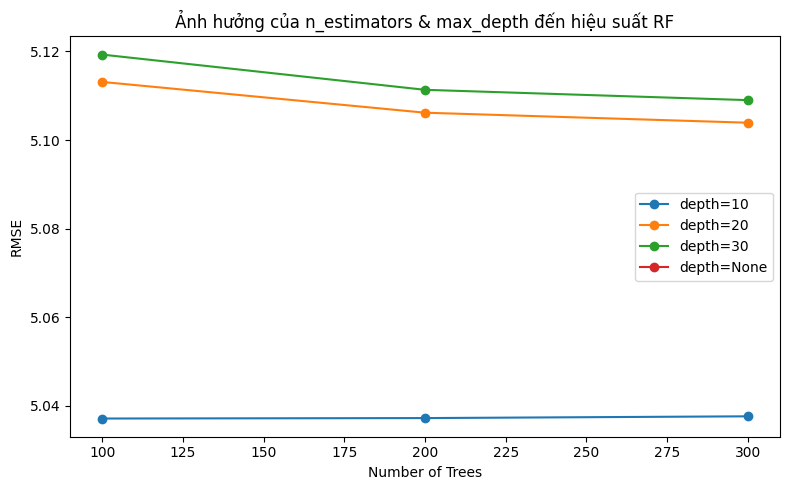

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for depth in max_depth_list:
    subset = results_df[results_df["max_depth"] == depth]
    plt.plot(subset["n_estimators"], subset["RMSE"], marker='o', label=f"depth={depth}")

plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.title("Ảnh hưởng của n_estimators & max_depth đến hiệu suất RF")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_rf, "../models/recovery_days_model_rf.joblib")

print("đã lưu")


đã lưu
